# Satelitendaten Geostandorten zuordnen

## Beispiel: Tracking der Internationalen Raumstation mit Dask

In diesem Notebook werden wir zwei APIs verwenden:

1. [Google Maps Geocoder](https://developers.google.com/maps/documentation/geocoding/guides-v3/overview)
2. [Open Notify API for ISS location](http://api.open-notify.org/)

Wir werden sie verwenden, um den ISS-Standort und die nächste Durchlaufzeit in Bezug auf eine Liste von Städten zu verfolgen. Um unsere Diagramme zu erstellen und Daten intelligent zu parallelisieren, verwenden wir Dask, insbesondere [Dask Delayed](../performance/dask.ipynb).

### 1. Importe

In [1]:
import datetime
import logging

from operator import itemgetter
from time import sleep

import httpx
import numpy as np

from dask import delayed
from sklearn.metrics import DistanceMetric

### 2. Logger

In [2]:
logger = logging.getLogger()

### 3. Latitude- und Longitude-Paare aus einer Liste von Städten

s.a. [Location APIs](https://locationiq.com/)

In [3]:
from geopy.geocoders import Nominatim


def get_lat_long(address):
    loc = Nominatim(user_agent="Geopy Library")
    get_loc = loc.geocode(address)
    return {
        "name": get_loc.address,
        "lat": get_loc.latitude,
        "long": get_loc.longitude,
    }

In [4]:
get_lat_long("Berlin, Germany")

{'name': 'Berlin, Deutschland', 'lat': 52.5173885, 'long': 13.3951309}

In [5]:
locations = []
for city in [
    "Seattle, Washington",
    "Miami, Florida",
    "Berlin, Germany",
    "Singapore",
    "Wellington, New Zealand",
    "Beirut, Lebanon",
    "Beijing, China",
    "Nairobi, Kenya",
    "Cape Town, South Africa",
    "Buenos Aires, Argentina",
]:
    locations.append(get_lat_long(city))
    sleep(2)

In [6]:
locations

[{'name': 'Seattle, King County, Washington, United States',
  'lat': 47.6038321,
  'long': -122.330062},
 {'name': 'Miami, Miami-Dade County, Florida, United States',
  'lat': 25.7741566,
  'long': -80.1935973},
 {'name': 'Berlin, Deutschland', 'lat': 52.5173885, 'long': 13.3951309},
 {'name': 'Singapore', 'lat': 1.357107, 'long': 103.8194992},
 {'name': 'Wellington, Wellington City, Wellington, 6011, New Zealand / Aotearoa',
  'lat': -41.2887953,
  'long': 174.7772114},
 {'name': 'بيروت, البسطة التحتا, باشورة, محافظة بيروت, لبنان',
  'lat': 33.8892265,
  'long': 35.5025585},
 {'name': '北京市, 中国', 'lat': 39.9057136, 'long': 116.3912972},
 {'name': 'Nairobi, Zimmerman, Soko ya Mawe, Nairobi, Kenya',
  'lat': -1.2890006,
  'long': 36.8172812},
 {'name': 'Cape Town, City of Cape Town, Western Cape, 8001, South Africa',
  'lat': -33.9288301,
  'long': 18.4172197},
 {'name': 'Buenos Aires, Comuna 1, Ciudad Autónoma de Buenos Aires, Argentina',
  'lat': -34.6095579,
  'long': -58.3887904}]

## 4. ISS-Daten abrufen und Durchlaufzeiten der Städte ermitteln

In [7]:
def get_spaceship_location():
    resp = httpx.get("http://api.open-notify.org/iss-now.json")
    location = resp.json()["iss_position"]
    return {
        "lat": float(location.get("latitude")),
        "long": float(location.get("longitude")),
    }

In [8]:
def great_circle_dist(lon1, lat1, lon2, lat2):
    dist = DistanceMetric.get_metric("haversine")
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    ll = [[lat1, lon1], [lat2, lon2]]
    kms = 6367
    return (kms * dist.pairwise(ll)).max()

In [9]:
def iss_dist_from_loc(issloc, loc):
    distance = great_circle_dist(
        issloc.get("long"),
        issloc.get("lat"),
        loc.get("long"),
        loc.get("lat"),
    )
    logger.info(f"ISS is {int(distance)}km from {loc.get('name')}")
    return distance

In [10]:
def iss_pass_near_loc(loc):
    resp = httpx.get(
        "http://api.open-notify.org/iss-pass.json",
        params={"lat": loc.get("lat"), "lon": loc.get("long")},
    )
    data = resp.json().get("response")[0]
    td = datetime.datetime.fromtimestamp(
        data.get("risetime"),
        tz=datetime.timezone.utc,
    ) - datetime.datetime.now(tz=datetime.timezone.utc)
    m, s = divmod(int(td.total_seconds()), 60)
    h, m = divmod(m, 60)
    logger.info(
        "ISS will pass near %s in %02d:%02d:%02d",
        loc.get("name"),
        h,
        m,
        s,
    )
    return td.total_seconds()

In [11]:
iss_dist_from_loc(get_spaceship_location(), locations[2])

INFO:root:ISS is ~12639km from Berlin, 10117, Germany


12639.759939298825

In [12]:
iss_pass_near_loc(locations[2])

INFO:root:ISS will pass near Berlin, 10117, Germany in 00:25:14


1514.253889

## 5. Erstellen einer `delayed`-Pipeline

In [13]:
output = []

for loc in locations:
    issloc = delayed(get_spaceship_location)()
    dist = delayed(iss_dist_from_loc)(issloc, loc)
    output.append((loc.get("name"), dist))

closest = delayed(lambda x: sorted(x, key=itemgetter(1))[0])(output)

In [14]:
closest

Delayed('lambda-6e51d667-459d-449d-8f2f-e9c7cdbf6b43')

## 6. DAG anzeigen

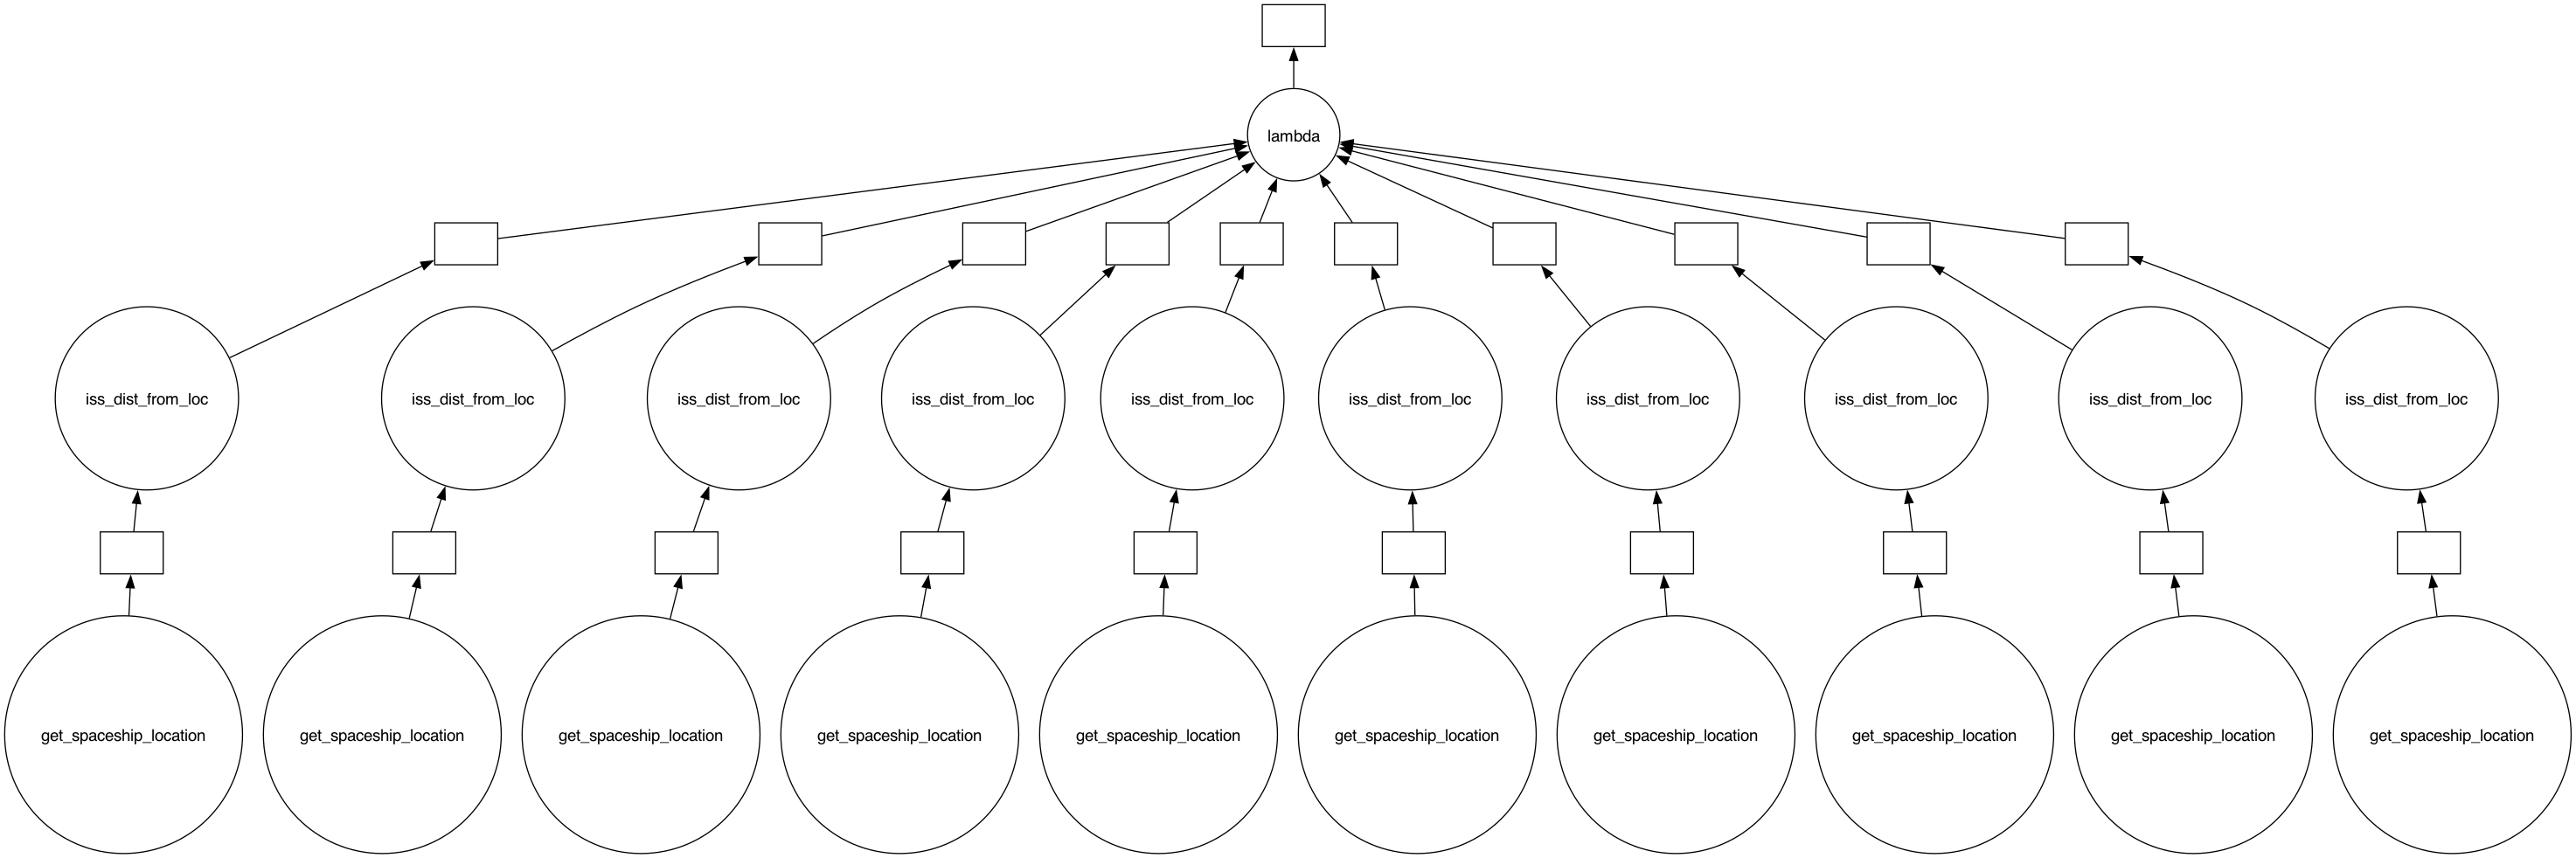

In [15]:
closest.visualize()

## 7. `compute()`

In [16]:
closest.compute()

INFO:root:ISS is ~4685km from Miami, Miami-Dade County, Florida, USA
INFO:root:ISS is ~15205km from Beirut, Beirut Governorate, Lebanon
INFO:root:ISS is ~5919km from Seattle, King County, Washington, USA
INFO:root:ISS is ~6279km from Autonomous City of Buenos Aires, Comuna 6, Autonomous City of Buenos Aires, Argentina
INFO:root:ISS is ~12625km from Berlin, 10117, Germany
INFO:root:ISS is ~13137km from Cape Town, City of Cape Town, Western Cape, 8001, South Africa
INFO:root:ISS is ~16194km from Singapore
INFO:root:ISS is ~16298km from Nairobi, Kenya
INFO:root:ISS is ~13905km from Beijing, Dongcheng District, Beijing, 100010, China
INFO:root:ISS is ~8405km from Wellington, Wellington City, Wellington, 6011, New Zealand


('Miami, Miami-Dade County, Florida, USA', 4685.887400314564)